## Stroke Prediction using Machine Learning

1. Title
2. Project Overview
3. Objectives
4. Dataset Description
5. Import Libraries
6. Load Dataset
7. Basic Information

## Dataset Description

The dataset contains demographic, lifestyle, and medical information of patients.

Features:

- gender                (jins(erkak/ayol/bola))
- age                   (yosh)
- hypertension          (gipertoniya->yuqori qon bosimi bor-yo'qligi(ha/yo'q))
- heart_disease         (yurak kasalligi bor-yo'qligi (ha/yo'q))
- ever_married          (turmush qurganligi (ha/yo'q))
- work_type             (ish turi(masalan:davlat xizmatchisi, xususiy, ish yo'q))
- Residence_type        (yashash joyi turi (shahar/qishloq))
- avg_glucose_level     (o'rtacha glyukoza darajasi)
- bmi                   (Tana vazni indeksi)
- smoking_status        (chekishholati(ilgari chekkan,hech qachon chekmagan,chekadi))

Target:

- stroke                (insult(insultga uchraganligi (ha/yo'q)))

# Import Libraries

In [1838]:
# import warnings
# warnings.filterwarnings("ignore")

In [1839]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Cross Validation
from sklearn.model_selection import cross_val_score

# Feature Selection
from sklearn.feature_selection import(
    mutual_info_classif,
    SelectKBest,
    f_classif,
    SelectFromModel,
)

# PCA (Dimensionality Reduction)
from sklearn.decomposition import PCA

## Load Dataset

In [1840]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5107 non-null   float64
 1   gender             5106 non-null   str    
 2   age                5107 non-null   float64
 3   hypertension       5104 non-null   float64
 4   heart_disease      5103 non-null   float64
 5   ever_married       5102 non-null   str    
 6   work_type          5107 non-null   str    
 7   Residence_type     5107 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5109 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(6), int64(1), str(5)
memory usage: 479.2 KB


In [1841]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1842]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234.0,Female,80.0,1.0,0.0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873.0,Female,81.0,0.0,0.0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723.0,Female,35.0,0.0,0.0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544.0,Male,51.0,0.0,0.0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679.0,Female,44.0,0.0,0.0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [1843]:
df.sample(5, random_state=42)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4688,40041.0,Male,31.0,0.0,0.0,No,Self-employed,Rural,64.85,23.0,Unknown,0
4478,55244.0,Male,40.0,0.0,0.0,Yes,Self-employed,Rural,65.29,28.3,never smoked,0
3849,70992.0,Female,8.0,0.0,0.0,No,children,Urban,74.42,22.5,Unknown,0
4355,38207.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,76.64,19.5,never smoked,0
3826,8541.0,Female,75.0,0.0,0.0,Yes,Govt_job,Rural,94.77,27.2,never smoked,0


In [1844]:
df.shape[0] # qatorlar soni
df.shape[1] # Ustunlar soni
df.shape # Umumiy qator va ustunlar soni

(5110, 12)

In [1845]:
# Columns Names
print(df.columns.tolist())

['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [1846]:
df.dtypes

id                   float64
gender                   str
age                  float64
hypertension         float64
heart_disease        float64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [1847]:
# numerical
df.describe().T     # Columnlarni qatorga tushirib qo'yadi

,count,mean,std,min,25%,50%,75%,max
id,5107.0,36525.644410,21157.947897,67.00,17748.50,36942.00,54669.00,72940.00
age,5107.0,43.210104,22.608654,0.08,25.00,45.00,61.00,82.00
hypertension,5104.0,0.097375,0.296496,0.00,0.00,0.00,0.00,1.00
heart_disease,5103.0,0.054086,0.226209,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5109.0,106.131296,45.272848,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.50,28.10,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.00,0.00,0.00,1.00


In [1848]:
# categorical summary
df.describe(include="str").T

,count,unique,top,freq
gender,5106,3,Female,2991
ever_married,5102,2,Yes,3347
work_type,5107,5,Private,2923
Residence_type,5107,2,Urban,2594
smoking_status,5109,4,never smoked,1892


In [1849]:
df.isnull().any()

id                    True
gender                True
age                   True
hypertension          True
heart_disease         True
ever_married          True
work_type             True
Residence_type        True
avg_glucose_level     True
bmi                   True
smoking_status        True
stroke               False
dtype: bool

### Missing Value

In [1850]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

print(tabulate(
    missing,
    headers="keys",
    tablefmt="pretty" # github, git
))

+-------------------+----------------+------------+
|                   | Missing Values | Percentage |
+-------------------+----------------+------------+
|        id         |      3.0       |    0.06    |
|      gender       |      4.0       |    0.08    |
|        age        |      3.0       |    0.06    |
|   hypertension    |      6.0       |    0.12    |
|   heart_disease   |      7.0       |    0.14    |
|   ever_married    |      8.0       |    0.16    |
|     work_type     |      3.0       |    0.06    |
|  Residence_type   |      3.0       |    0.06    |
| avg_glucose_level |      1.0       |    0.02    |
|        bmi        |     201.0      |    3.93    |
|  smoking_status   |      1.0       |    0.02    |
|      stroke       |      0.0       |    0.0     |
+-------------------+----------------+------------+


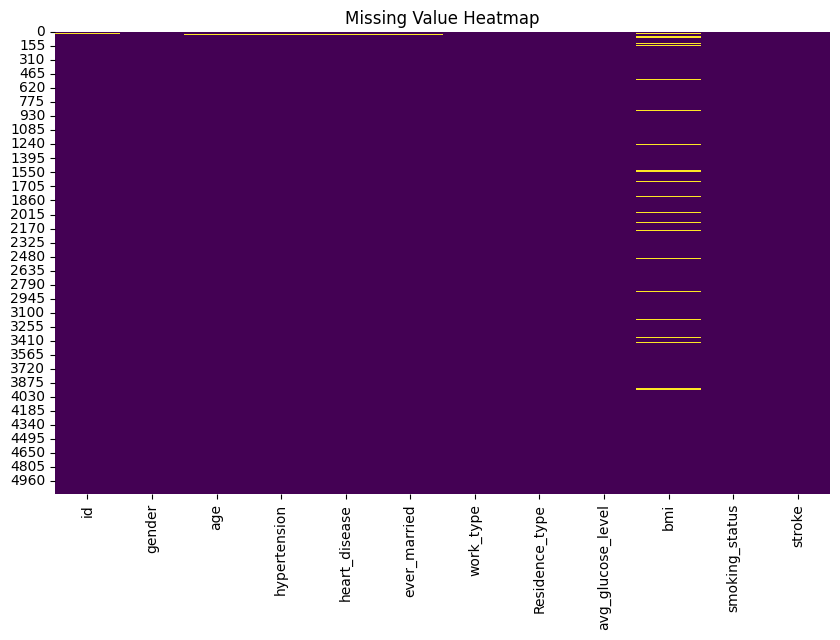

In [1851]:
# Missing value visualization
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

In [1852]:
# Dublicates Records
duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [1853]:
# Unique Values
unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

print(tabulate(
    unique,
    headers="keys",
    tablefmt="pretty"
))

+-------------------+---------------+
|                   | Unique Values |
+-------------------+---------------+
|        id         |     5107      |
|      gender       |       3       |
|        age        |      104      |
|   hypertension    |       2       |
|   heart_disease   |       2       |
|   ever_married    |       2       |
|     work_type     |       5       |
|  Residence_type   |       2       |
| avg_glucose_level |     3978      |
|        bmi        |      418      |
|  smoking_status   |       4       |
|      stroke       |       2       |
+-------------------+---------------+


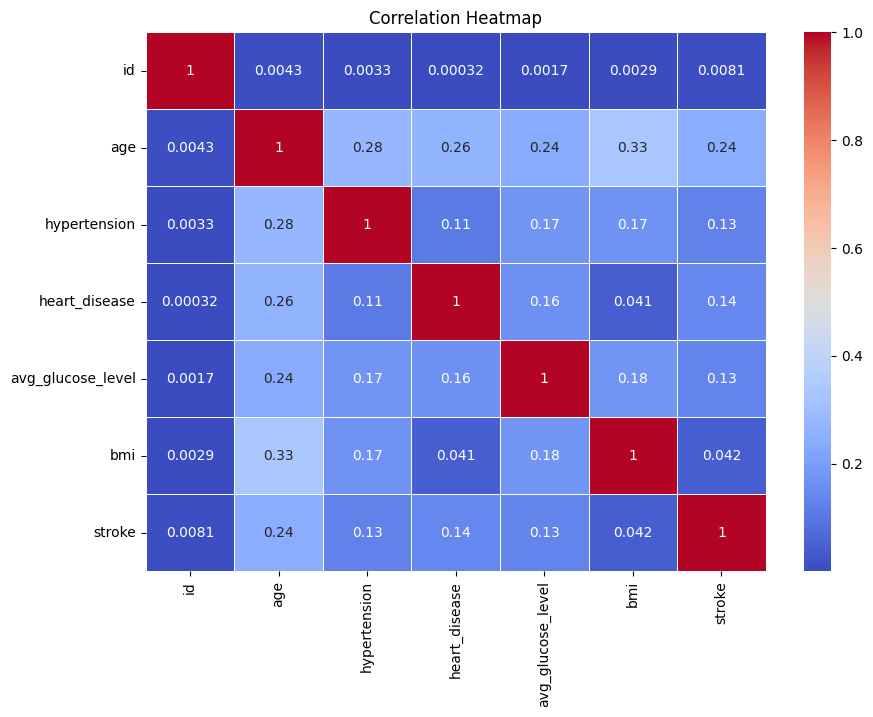

In [1854]:
## Correlation Analysis
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidth=0.5
)

plt.title("Correlation Heatmap")
plt.show()

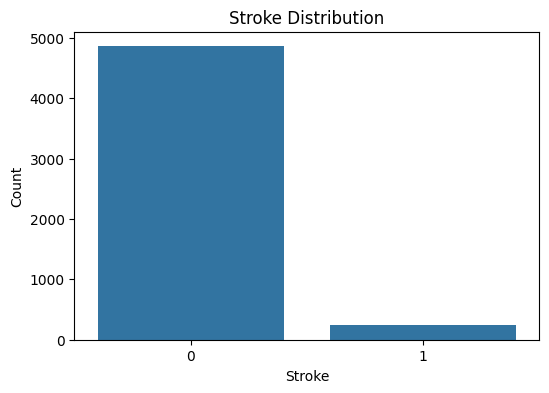

In [1855]:
# Target Variable Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="stroke",
    data=df
)

plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [1856]:
stroke_counts = df["stroke"].value_counts()

print(tabulate(
    pd.DataFrame(stroke_counts),
    headers=["Count"],
    tablefmt="pretty"
))

# The dataset is highly imbalanced because the number of patients without stroke is much larger than the number of stroke cases
# This imbalance should be considered during model evaluation

+---+-------+
|   | Count |
+---+-------+
| 0 | 4861  |
| 1 |  249  |
+---+-------+


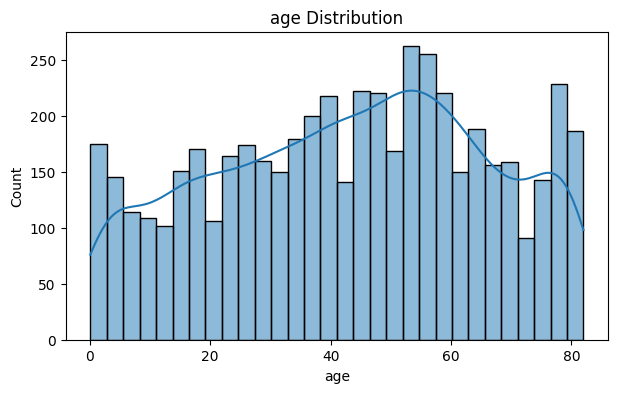

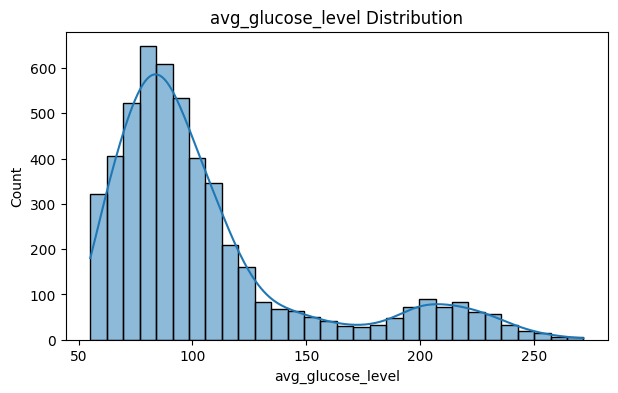

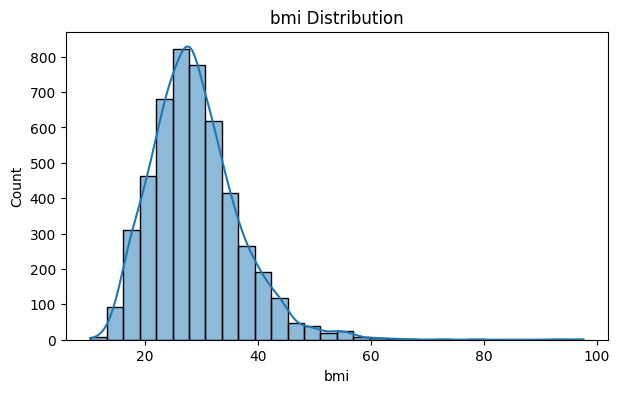

In [1857]:
# Numerical Feature Distribution
numerical_columns = [
    "age",
    "avg_glucose_level",
    "bmi"
]

for column in numerical_columns:
    plt.figure(figsize=(7,4))

    sns.histplot(
        df[column],
        kde=True,
        bins=30
    )

    plt.title(f"{column} Distribution")
    plt.show()

# The numerical features have different distributions 
# Age appears relatively spread across different age groups, 
# while average glucose level and BMI show slight right-skewed distributions

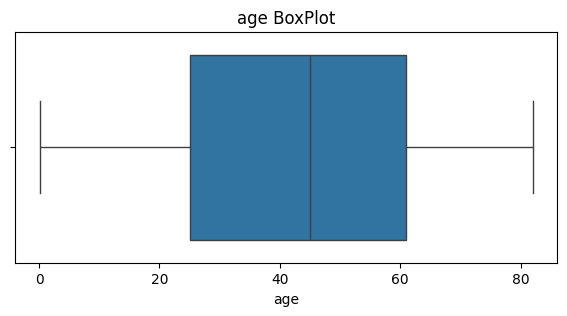

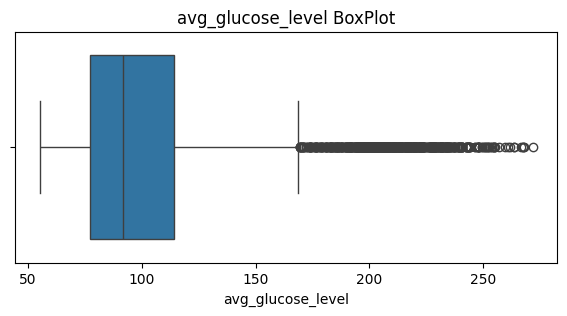

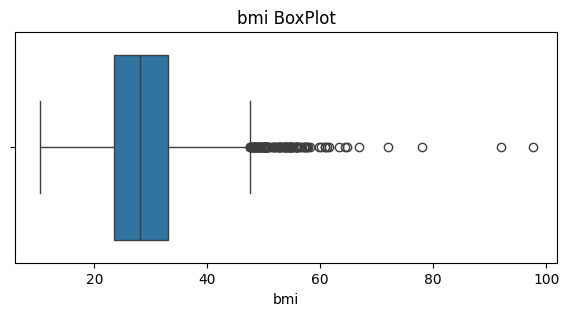

In [1858]:
# Boxplots of Numerical Features
for column in numerical_columns:
    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"{column} BoxPlot")
    plt.show()

### Categorical Feature Analysis

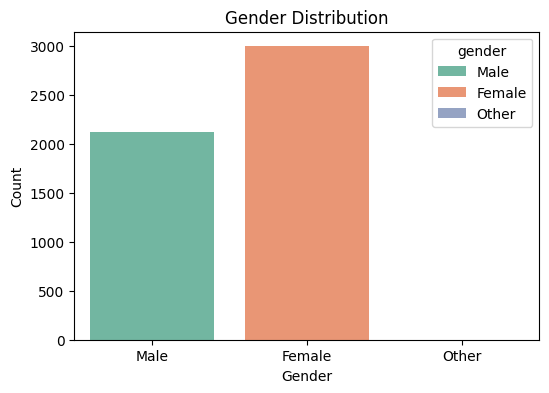

In [1859]:
# Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=df,
    hue='gender',
    palette="Set2"  # palette="viridis"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [1860]:
gender_counts = pd.DataFrame(df["gender"].value_counts())

print(tabulate(
    gender_counts,
    headers=["Count"],
    tablefmt="pretty"
))

# Most patients in the dataset are female, followed by male
# There is also a very small number of records labeled as "Other"

+--------+-------+
|        | Count |
+--------+-------+
| Female | 2991  |
|  Male  | 2114  |
| Other  |   1   |
+--------+-------+


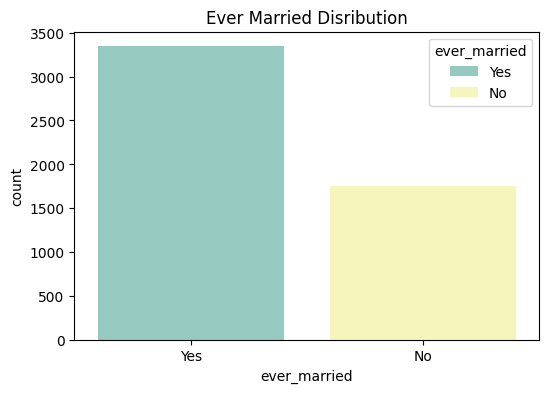

In [1861]:
# Ever Married Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="ever_married",
    data=df,
    hue="ever_married",
    palette="Set3"
)

plt.title("Ever Married Disribution")
plt.show()

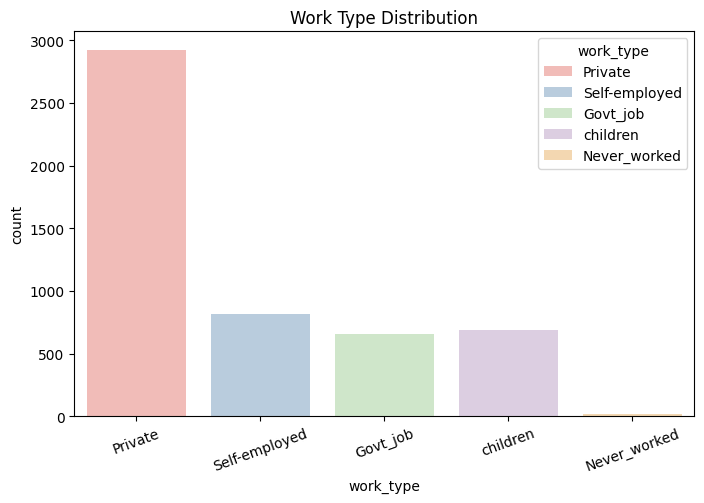

In [1862]:
# Work Type Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x="work_type",
    hue="work_type",
    data=df,
    palette="Pastel1"
)

plt.xticks(rotation=20)
plt.title("Work Type Distribution")
plt.show()

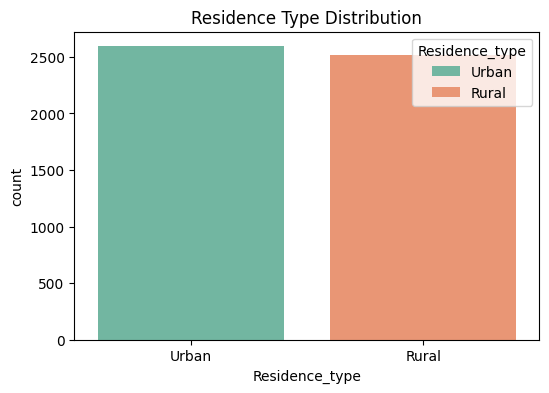

In [1863]:
# Residence Type Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="Residence_type",
    hue="Residence_type",
    data=df,
    palette="Set2"
)

plt.title("Residence Type Distribution")
plt.show()

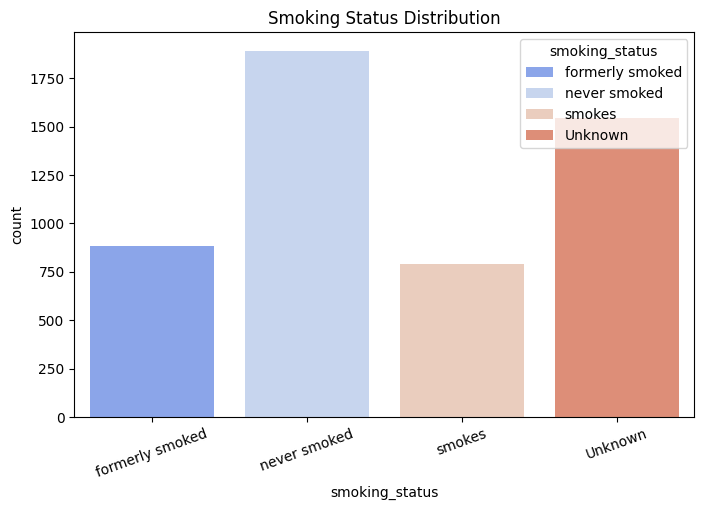

In [1864]:
# Smoking Status Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x="smoking_status",
    hue="smoking_status",
    data=df,
    palette="coolwarm"
)

plt.xticks(rotation=20)
plt.title("Smoking Status Distribution")
plt.show()

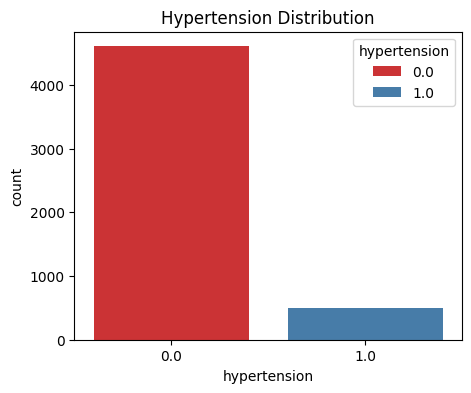

In [1865]:
# Hypertension Distribution
plt.figure(figsize=(5,4))

sns.countplot(
    x="hypertension",
    hue="hypertension",
    data=df,
    palette="Set1"
)

plt.title("Hypertension Distribution")
plt.show()

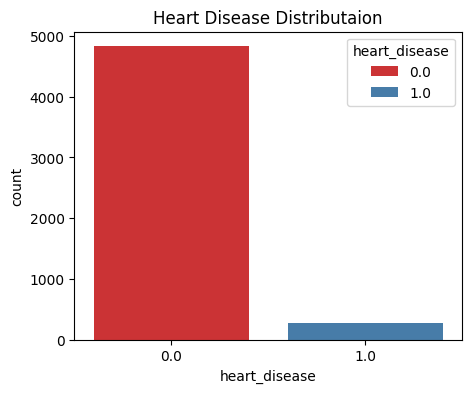

In [1866]:
# Heart Disease Distribution
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="heart_disease",
    hue="heart_disease",
    palette="Set1"
)

plt.title("Heart Disease Distributaion")
plt.show()

### Relationship Between Features and Stroke

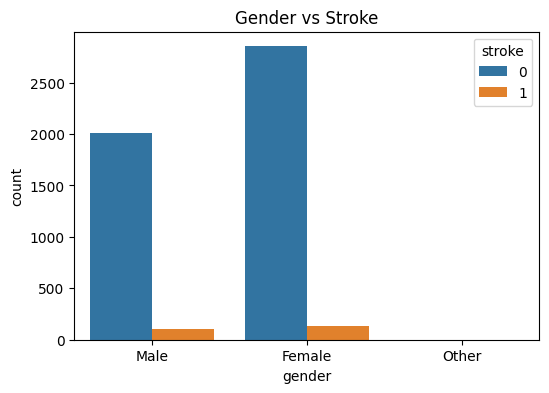

In [1867]:
# Gender vs Stroke
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="stroke",
)

plt.title("Gender vs Stroke")
plt.show()

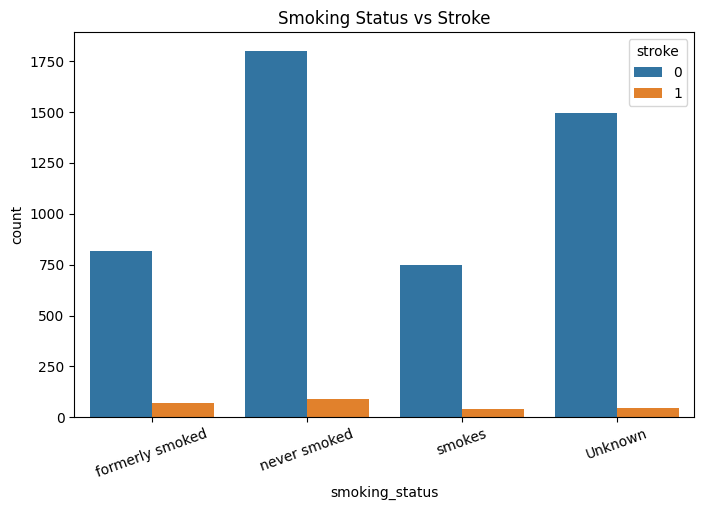

In [1868]:
# Smoking Statue vs Stroke
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="smoking_status",
    hue="stroke"
)

plt.xticks(rotation=20)
plt.title("Smoking Status vs Stroke")
plt.show()

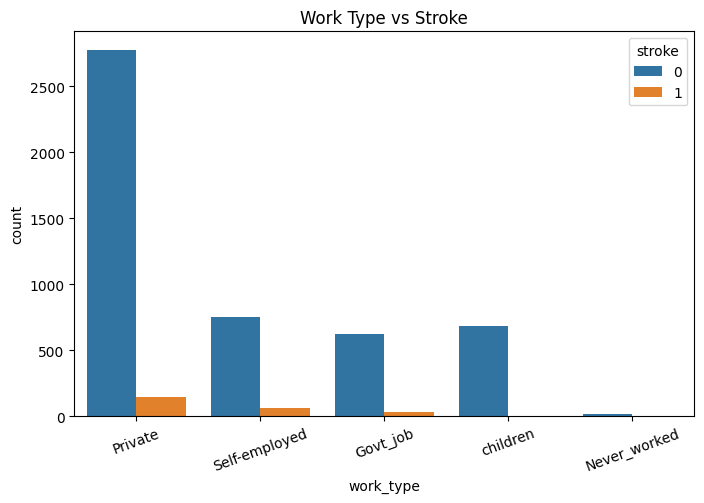

In [1869]:
# Work Type vs Stroke
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="work_type",
    hue="stroke"
)

plt.xticks(rotation=20)
plt.title("Work Type vs Stroke")
plt.show()

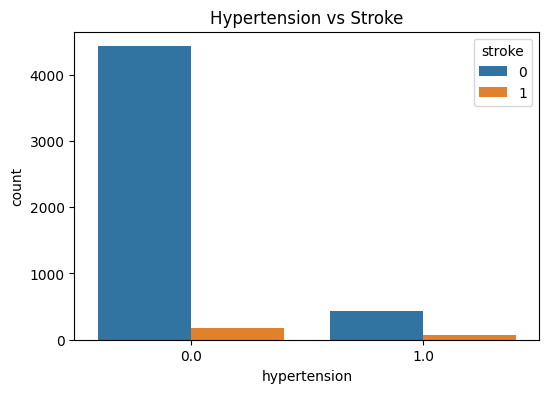

In [1870]:
# Hypertension vs Stroke
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="hypertension",
    hue="stroke"
)

plt.title("Hypertension vs Stroke")
plt.show()

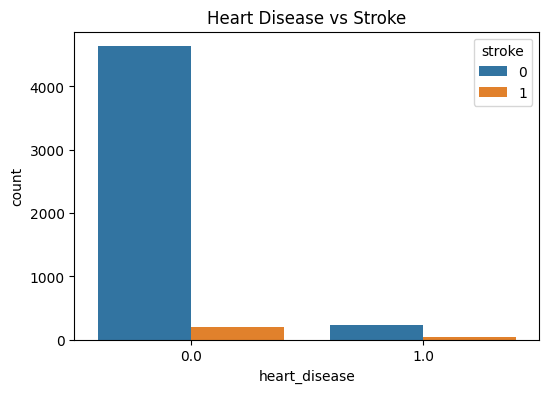

In [1871]:
# Heart Disease vs Stroke
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="heart_disease",
    hue="stroke"
)

plt.title("Heart Disease vs Stroke")
plt.show()

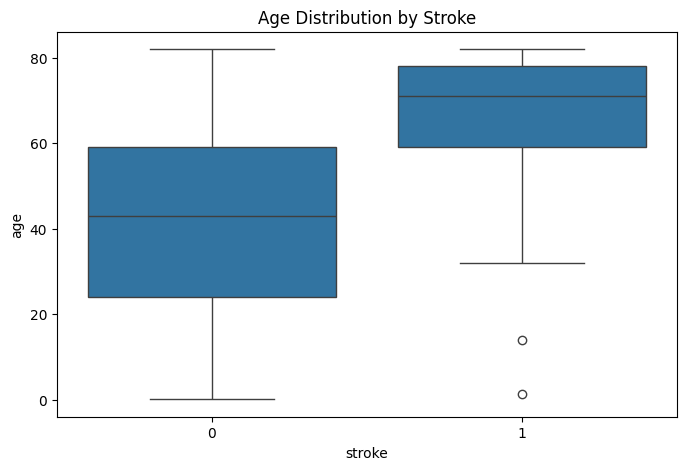

In [1872]:
# Age Distribution by Stroke
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stroke",
    y="age"
)

plt.title("Age Distribution by Stroke")
plt.show()

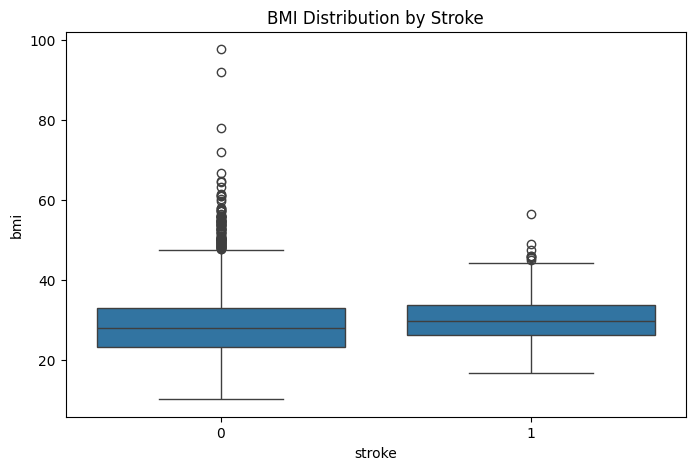

In [1873]:
# BMI Distribution by Stroke
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stroke",
    y="bmi"
)

plt.title("BMI Distribution by Stroke")
plt.show()

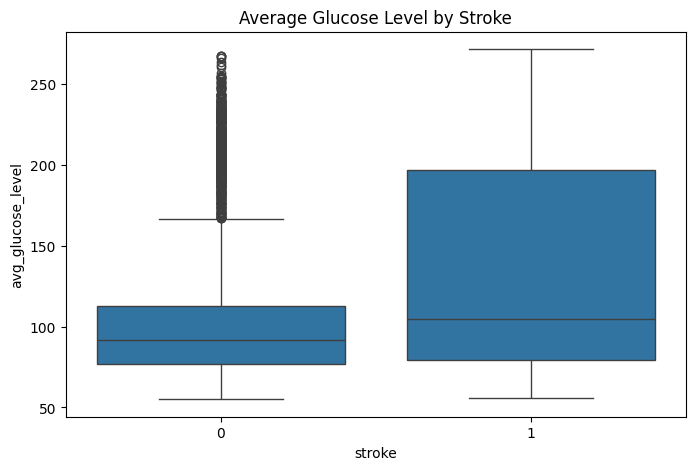

In [1874]:
# Average Glucose Level by Stroke
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stroke",
    y="avg_glucose_level"
)

plt.title("Average Glucose Level by Stroke")
plt.show()

# Summary of EDA

### Key Findings

- The dataset contains missing values mainly in the BMI feature.
- Stroke cases are highly imbalanced.
- Age appears to have a strong relationship with stroke occurrence.
- Patients with hypertension and heart disease show a higher proportion of stroke cases.
- Average glucose level also appears to differ between stroke and non-stroke patients.
- Some numerical features contain outliers.
- These findings motivate the use of preprocessing and feature engineering before model development.

##########################################################
##########################################################
##########################################################

# Baseline Machine Learning Model

In this section, a baseline classification model is developed using basic preprocessing techniques.

The preprocessing steps include:

- Removing unnecessary columns
- Handling missing values
- Encoding categorical variables
- Feature scaling
- Splitting the dataset
- Training multiple classification algorithms
- Evaluating model performance

In [1875]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1876]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5107 non-null   float64
 1   gender             5106 non-null   str    
 2   age                5107 non-null   float64
 3   hypertension       5104 non-null   float64
 4   heart_disease      5103 non-null   float64
 5   ever_married       5102 non-null   str    
 6   work_type          5107 non-null   str    
 7   Residence_type     5107 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5109 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(6), int64(1), str(5)
memory usage: 479.2 KB


## Preprocessing

In [1877]:
df.isnull().sum()

id                     3
gender                 4
age                    3
hypertension           6
heart_disease          7
ever_married           8
work_type              3
Residence_type         3
avg_glucose_level      1
bmi                  201
smoking_status         1
stroke                 0
dtype: int64

In [1878]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from pandas.api.types import is_numeric_dtype
df = df.copy()

In [1879]:
class DataPreprocessing:
    """
    Ma'lumotlarni tozalash va kodlash uchun to'liq pipeline
    """

    def __init__(self, df):
        self.df=df.copy()

    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if is_numeric_dtype(self.df[col]):
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
        return self

    def encodla(self):
        encoder=LabelEncoder()
        for col in self.df.columns:
            if self.df[col].dtype=="str":
                if self.df[col].nunique()<6:
                    dummies=pd.get_dummies(self.df[col],prefix=col,dtype=int)
                    self.df=pd.concat([self.df.drop(columns=[col]),dummies],axis=1)
                else:
                    self.df[col]=encoder.fit_transform(self.df[col])
        return self

    def scale_qil(self):
        scaler=MinMaxScaler()
        num_col = self.df.select_dtypes(include=["int64","float64"]).columns.drop("stroke")
        self.df[num_col] = scaler.fit_transform(self.df[num_col])
        return self

In [1880]:
dp = DataPreprocessing(df)
dp.tozala().encodla().scale_qil()
df = dp.df
print(f"\nPreprocessing jarayoni tugadi")


Preprocessing jarayoni tugadi


In [1881]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5110 non-null   float64
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   float64
 3   heart_disease                   5110 non-null   float64
 4   avg_glucose_level               5110 non-null   float64
 5   bmi                             5110 non-null   float64
 6   stroke                          5110 non-null   int64  
 7   gender_Female                   5110 non-null   float64
 8   gender_Male                     5110 non-null   float64
 9   gender_Other                    5110 non-null   float64
 10  ever_married_No                 5110 non-null   float64
 11  ever_married_Yes                5110 non-null   float64
 12  work_type_Govt_job              5110 non-null

## Model training va prediction

In [1882]:
# Target va featurega ajratib olish
X = df.drop(columns=["stroke"])
y = df["stroke"]

In [1883]:
# Train va testga ajratib olish
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [1884]:
# Modellar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [1885]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "SVC": SVC(class_weight="balanced", probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

In [1886]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [1887]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
print(X_train.select_dtypes(include="str").columns)

Index([], dtype='str')


In [1888]:
baseline_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    baseline_results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average="weighted", zero_division=0),
        recall_score(y_test, preds, average="weighted",zero_division=0),
        f1_score(y_test, preds, average="weighted",zero_division=0),
    ])

baseline_df = pd.DataFrame(baseline_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1_score"])
print(baseline_df)

                 Model  Accuracy  Precision    Recall  F1_score
0  Logistic Regression  0.735812   0.931994  0.735812  0.804165
1        Decision Tree  0.912916   0.897028  0.912916  0.904509
2        Random Forest  0.939335   0.882350  0.939335  0.909951
3                  SVC  0.749511   0.925951  0.749511  0.813401
4              XGBoost  0.938356   0.915200  0.938356  0.918986


### Tabulate

In [1889]:
from tabulate import tabulate
print(tabulate(baseline_df, headers="keys", tablefmt="github", showindex=False))

| Model               |   Accuracy |   Precision |   Recall |   F1_score |
|---------------------|------------|-------------|----------|------------|
| Logistic Regression |   0.735812 |    0.931994 | 0.735812 |   0.804165 |
| Decision Tree       |   0.912916 |    0.897028 | 0.912916 |   0.904509 |
| Random Forest       |   0.939335 |    0.88235  | 0.939335 |   0.909951 |
| SVC                 |   0.749511 |    0.925951 | 0.749511 |   0.813401 |
| XGBoost             |   0.938356 |    0.9152   | 0.938356 |   0.918986 |


In [1890]:
best_baseline = baseline_df.sort_values("F1_score", ascending=False).iloc[0:].round(2)
print("Eng yaxshi baseline model:")
print(best_baseline)

Eng yaxshi baseline model:
                 Model  Accuracy  Precision  Recall  F1_score
4              XGBoost      0.94       0.92    0.94      0.92
2        Random Forest      0.94       0.88    0.94      0.91
1        Decision Tree      0.91       0.90    0.91      0.90
3                  SVC      0.75       0.93    0.75      0.81
0  Logistic Regression      0.74       0.93    0.74      0.80


##

# Advanced Model

In [1891]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [1892]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5107 non-null   float64
 1   gender             5106 non-null   str    
 2   age                5107 non-null   float64
 3   hypertension       5104 non-null   float64
 4   heart_disease      5103 non-null   float64
 5   ever_married       5102 non-null   str    
 6   work_type          5107 non-null   str    
 7   Residence_type     5107 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5109 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(6), int64(1), str(5)
memory usage: 479.2 KB


In [1893]:
# Remove ID column
df.drop("id", axis=1, inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1894]:
# Seperate Numrical and Categorical Features

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

print("Numerical Features")
print(numerical_columns)

print()

print("Categorical Features")
print(categorical_columns)

Numerical Features
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Categorical Features
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [1895]:
# Handle Missing Values using KNN Imputer
knn = KNNImputer(n_neighbors=5)
df[numerical_columns] = knn.fit_transform(df[numerical_columns])
df.isnull().sum()

gender               4
age                  0
hypertension         0
heart_disease        0
ever_married         8
work_type            3
Residence_type       3
avg_glucose_level    0
bmi                  0
smoking_status       1
stroke               0
dtype: int64

In [1896]:
# Encode Binary Features
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

binary_columns

['gender', 'ever_married', 'Residence_type']

In [1897]:
le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

In [1898]:
# One-Hot Encoding
multi_columns = [
    "work_type",
    "smoking_status"
]

df = pd.get_dummies(
    df,
    columns=multi_columns,
    drop_first=True
)

In [1899]:
# Separate Features and Target
X = df.drop("stroke", axis=1)
y = df["stroke"]
print(X.shape)
print(y.shape)

(5110, 15)
(5110,)


In [1900]:
# Feature Scaling
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(X),
    columns = X.columns
)

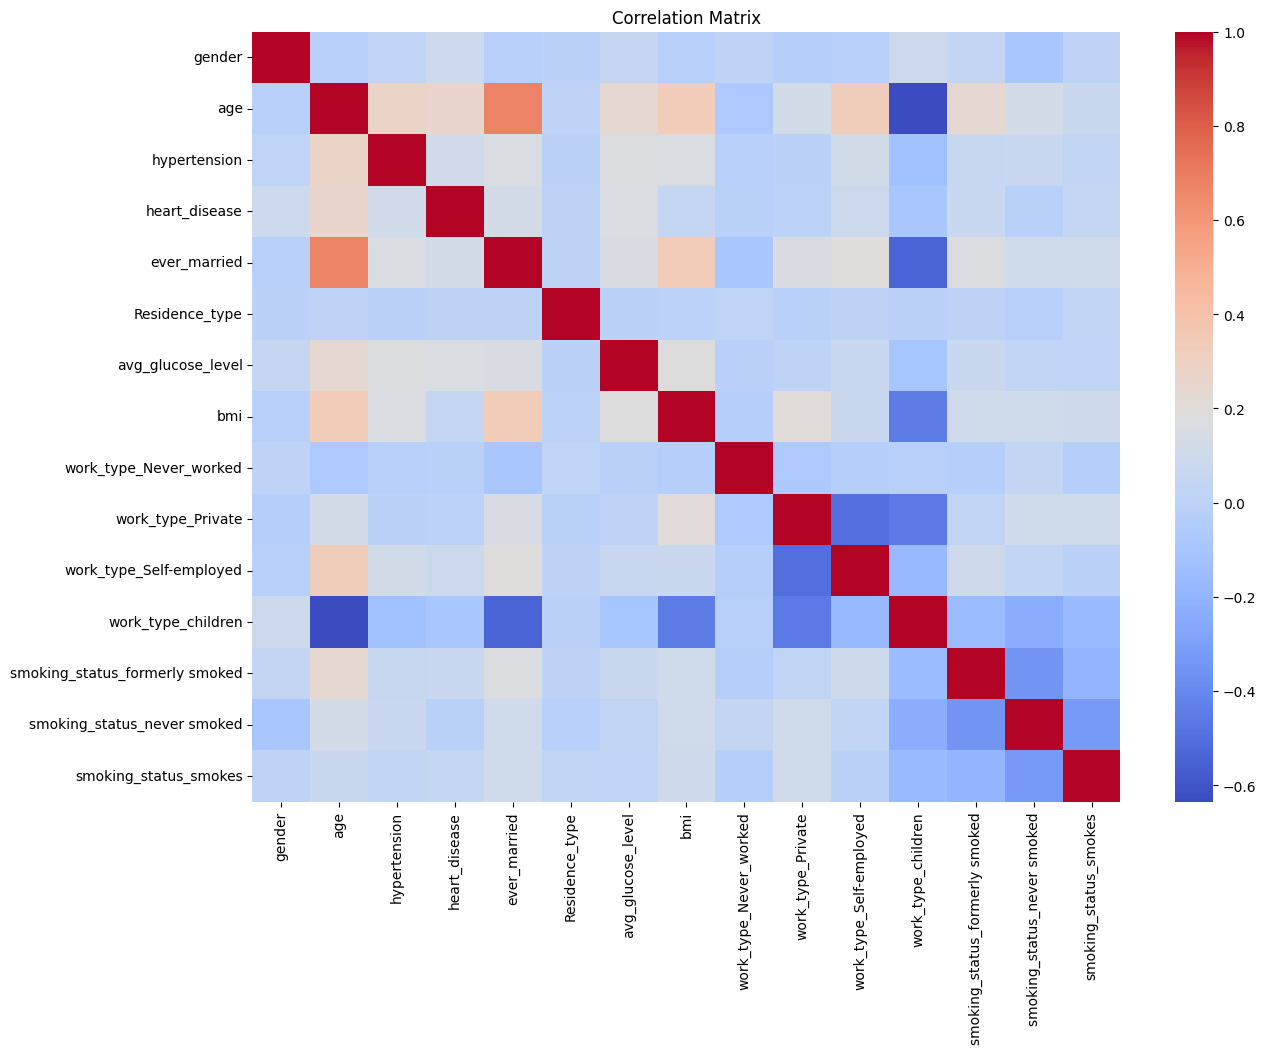

In [1901]:
# Correlation Matrix
corr_matrix = X.corr()
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [1902]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

upper.max().sort_values(ascending=False).head(10)

ever_married                      0.677791
work_type_children                0.634178
work_type_Self-employed           0.504704
smoking_status_never smoked       0.350934
bmi                               0.340885
smoking_status_smokes             0.327653
hypertension                      0.276803
heart_disease                     0.264722
avg_glucose_level                 0.238556
smoking_status_formerly smoked    0.236290
dtype: float64

In [1903]:
# Correlation Filtering
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

threshold = 0.60
drop_features = [
    column

    for column in upper.columns

    if any(
        upper[column] > threshold
    )
]
drop_features

X_filtered = X.drop(columns=drop_features)

print("Original Features: ", X.shape[1])
print("Remaining Features: ", X_filtered.shape[1])

Original Features:  15
Remaining Features:  13


In [1904]:
feature_summary = pd.DataFrame({
    "Orginal Features":[X.shape[1]],
    "Remaining Features":[X_filtered.shape[1]],
    "Removed Features":[len(drop_features)]
})
print(tabulate(feature_summary,headers="keys",tablefmt="github"))

|    |   Orginal Features |   Remaining Features |   Removed Features |
|----|--------------------|----------------------|--------------------|
|  0 |                 15 |                   13 |                  2 |


In [1905]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42, stratify=y
)
print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 13)
Testing Set : (1022, 13)


In [1906]:
# Define Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [1907]:
# Train and Evaluate Models
results = []

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [1908]:
# Performance Comparison
results_df = pd.DataFrame(
    results,
    columns = [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="grid",
        showindex=False,
        floatfmt=".2f"
    )
)

+------------------------+------------+-------------+----------+------------+
| Model                  |   Accuracy |   Precision |   Recall |   F1-score |
+========================+============+=============+==========+============+
| Logistic Regression    |       0.74 |        0.94 |     0.74 |       0.81 |
+------------------------+------------+-------------+----------+------------+
| Decision Tree          |       0.93 |        0.92 |     0.93 |       0.92 |
+------------------------+------------+-------------+----------+------------+
| Random Forest          |       0.95 |        0.90 |     0.95 |       0.93 |
+------------------------+------------+-------------+----------+------------+
| Support Vector Machine |       0.78 |        0.94 |     0.78 |       0.84 |
+------------------------+------------+-------------+----------+------------+
| XGBoost                |       0.94 |        0.92 |     0.94 |       0.93 |
+------------------------+------------+-------------+----------+

In [1909]:
# print(np.unique(y_pred, return_counts=True))
# print(confusion_matrix(y_test, y_pred))
# print(df["stroke"].value_counts())


In [1910]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score", ascending=False
).iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : XGBoost


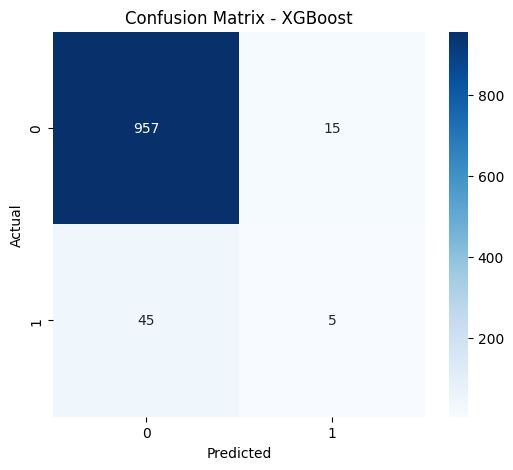

In [1911]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1912]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.25      0.10      0.14        50

    accuracy                           0.94      1022
   macro avg       0.60      0.54      0.56      1022
weighted avg       0.92      0.94      0.93      1022



In [1913]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_filtered,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)
print()
print("Average Accuracy :", cv_scores.mean())

Cross Validation Scores
[0.93737769 0.95009785 0.93444227 0.94716243 0.9334638 ]

Average Accuracy : 0.940508806262231


# Mutual Information

In [1914]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1915]:
# Remove ID Column
df.drop("id", axis=1, inplace=True)

### Handle Missing Values

In [1916]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

knn = KNNImputer(n_neighbors=5)
df[numerical_columns] = knn.fit_transform(df[numerical_columns])

mode = SimpleImputer(strategy="most_frequent")

df[categorical_columns] = mode.fit_transform(df[categorical_columns])

# Agar targetda Nan bo'lsa
df = df.dropna(subset=["stroke"])
df.reset_index(drop=True, inplace=True)

In [1917]:
# Encoding
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=["work_type","smoking_status"], drop_first=True)


In [1918]:
# Feature Scaling
X = df.drop("stroke", axis=1)
y = df["stroke"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [1919]:
# Mutual Information Feature Selection
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

mi_scores

age                               0.037758
heart_disease                     0.012146
bmi                               0.012125
hypertension                      0.007090
avg_glucose_level                 0.006533
smoking_status_never smoked       0.005306
smoking_status_formerly smoked    0.004977
work_type_children                0.004730
ever_married                      0.003709
work_type_Private                 0.002255
Residence_type                    0.002142
gender                            0.000000
work_type_Never_worked            0.000000
work_type_Self-employed           0.000000
smoking_status_smokes             0.000000
dtype: float64

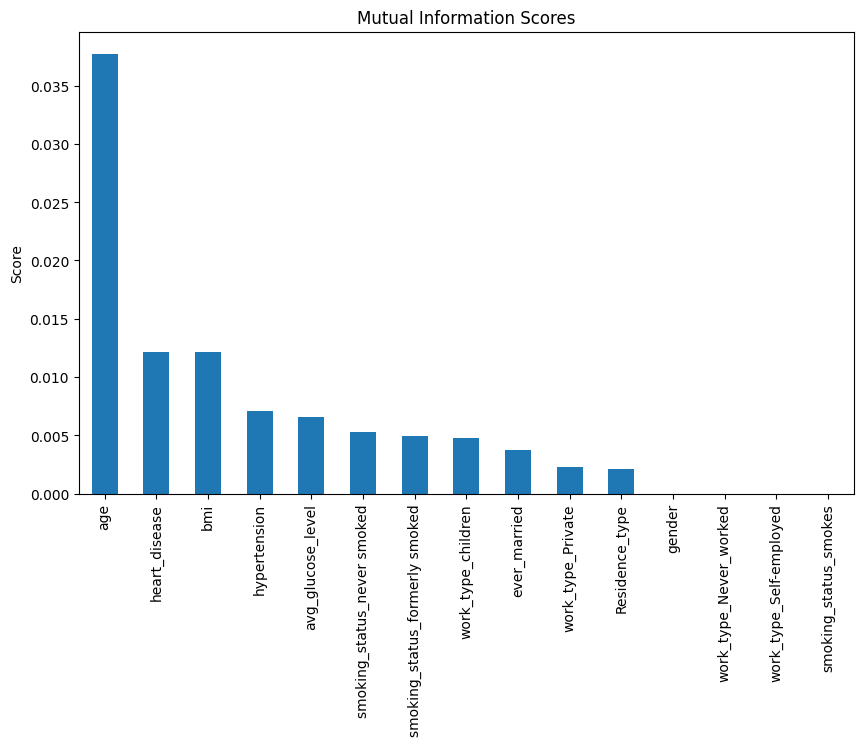

In [1920]:
plt.figure(figsize=(10,6))
mi_scores.plot(kind="bar")
plt.title("Mutual Information Scores")
plt.ylabel("Score")
plt.show()

In [1921]:
# Select Important Features

selected_features = mi_scores.head(10).index.tolist()
selected_features

['age',
 'heart_disease',
 'bmi',
 'hypertension',
 'avg_glucose_level',
 'smoking_status_never smoked',
 'smoking_status_formerly smoked',
 'work_type_children',
 'ever_married',
 'work_type_Private']

In [1922]:
X_selected = X[selected_features]

print("Selected Features")

print(selected_features)

Selected Features
['age', 'heart_disease', 'bmi', 'hypertension', 'avg_glucose_level', 'smoking_status_never smoked', 'smoking_status_formerly smoked', 'work_type_children', 'ever_married', 'work_type_Private']


In [1923]:
# Feature Selection Summary
summary = pd.DataFrame({
    "Original Features": [X.shape[1]],
    "Selected Features": [X_selected.shape[1]]
})

print(
    tabulate(
        summary,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------+-------------------+
| Original Features | Selected Features |
+-------------------+-------------------+
|        15         |        10         |
+-------------------+-------------------+


In [1924]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 10)
Testing Set : (1022, 10)


In [1925]:
# Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [1926]:
# Train and Evaluate Models
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [1927]:
# Preformance Comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

results_df = results_df.round(2)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+------------------------+----------+-----------+--------+----------+
|         Model          | Accuracy | Precision | Recall | F1-score |
+------------------------+----------+-----------+--------+----------+
|  Logistic Regression   |   0.74   |   0.93    |  0.74  |   0.81   |
|     Decision Tree      |   0.91   |   0.91    |  0.91  |   0.91   |
|     Random Forest      |   0.94   |   0.91    |  0.94  |   0.91   |
| Support Vector Machine |   0.75   |   0.92    |  0.75  |   0.81   |
|        XGBoost         |   0.93   |    0.9    |  0.93  |   0.91   |
+------------------------+----------+-----------+--------+----------+


In [1928]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Decision Tree


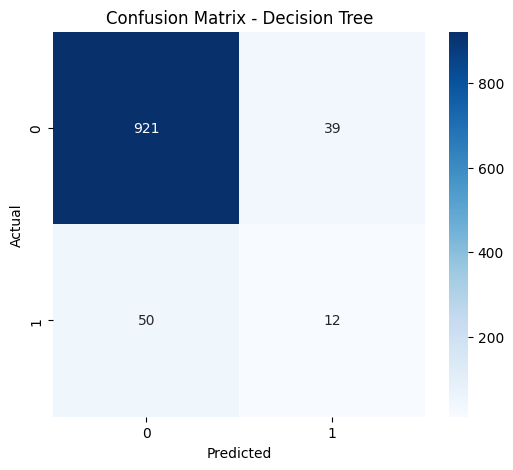

In [1929]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1930]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       960
           1       0.24      0.19      0.21        62

    accuracy                           0.91      1022
   macro avg       0.59      0.58      0.58      1022
weighted avg       0.91      0.91      0.91      1022



In [1931]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy :", round(cv_scores.mean(), 4))

Cross Validation Scores
[0.91780822 0.91976517 0.92172211 0.92270059 0.92465753]

Average Accuracy : 0.9213


# ANOVA F-Test 

In [1932]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1933]:
# Remove ID
df.drop("id", axis=1, inplace=True)

## Handle Missing Values

In [1934]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

knn = KNNImputer(n_neighbors=5)
df[numerical_columns] = knn.fit_transform(df[numerical_columns])
mode = SimpleImputer(strategy="most_frequent")
df[categorical_columns] = mode.fit_transform(df[categorical_columns])
df = df.dropna(subset=["stroke"])
df.reset_index(drop=True, inplace=True)

In [1935]:
# Encoding
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(
    df,
    columns=[
        "work_type",
        "smoking_status"
    ],
    drop_first=True
)

In [1936]:
# Feature Scaling
X = df.drop("stroke", axis=1)

y = df["stroke"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

### ANOVA F-TEST Feature Selection

In [1937]:
selector = SelectKBest(score_func=f_classif,k=10)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
selected_features

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Self-employed',
       'work_type_children', 'smoking_status_formerly smoked'],
      dtype='str')

In [1938]:
anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "F-Score": selector.scores_,
    "Selected": selector.get_support()
})

anova_scores = anova_scores.sort_values(
    by="F-Score",
    ascending=False
)

anova_scores

,Feature,F-Score,Selected
1,age,317.938888,True
3,heart_disease,100.121653,True
6,avg_glucose_level,88.714509,True
2,hypertension,85.092118,True
4,ever_married,64.901479,True
11,work_type_children,36.184470,True
12,smoking_status_formerly smoked,21.376277,True
10,work_type_Self-employed,18.357161,True
7,bmi,7.842398,True
5,Residence_type,1.509419,True


In [1939]:
# Selected Features
X_selected = pd.DataFrame(X_selected,columns=selected_features)

X_selected.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Self-employed,work_type_children,smoking_status_formerly smoked
0,1.052604,-0.328865,4.18151,0.723256,0.983695,2.707557,0.985739,-0.436563,-0.394112,2.184951
1,0.787132,-0.328865,-0.23966,0.723256,-1.016576,2.122550,0.313623,2.290621,-0.394112,-0.457676
2,1.627792,-0.328865,4.18151,0.723256,-1.016576,-0.004729,0.457832,-0.436563,-0.394112,-0.457676
3,0.256189,-0.328865,-0.23966,0.723256,0.983695,1.438127,0.702472,-0.436563,-0.394112,-0.457676
4,1.583546,3.045637,-0.23966,0.723256,-1.016576,1.501974,-0.636608,2.290621,-0.394112,-0.457676


In [1940]:
# Feature Selection Summary
summary = pd.DataFrame({
    "Original Features":[X.shape[1]],
    "Selected Features":[X_selected.shape[1]]
})
summary

,Original Features,Selected Features
0,15,10


In [1941]:
print(
    tabulate(
        summary,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------+-------------------+
| Original Features | Selected Features |
+-------------------+-------------------+
|        15         |        10         |
+-------------------+-------------------+


In [1942]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 10)
Testing Set : (1022, 10)


In [1943]:
# Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [1944]:
# Train and Evaluate Models
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [1945]:
# Preformance Comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

results_df = results_df.round(2)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+------------------------+----------+-----------+--------+----------+
|         Model          | Accuracy | Precision | Recall | F1-score |
+------------------------+----------+-----------+--------+----------+
|  Logistic Regression   |   0.75   |   0.93    |  0.75  |   0.81   |
|     Decision Tree      |   0.92   |   0.91    |  0.92  |   0.92   |
|     Random Forest      |   0.94   |   0.94    |  0.94  |   0.91   |
| Support Vector Machine |   0.75   |   0.92    |  0.75  |   0.81   |
|        XGBoost         |   0.94   |   0.92    |  0.94  |   0.92   |
+------------------------+----------+-----------+--------+----------+


In [1946]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Decision Tree


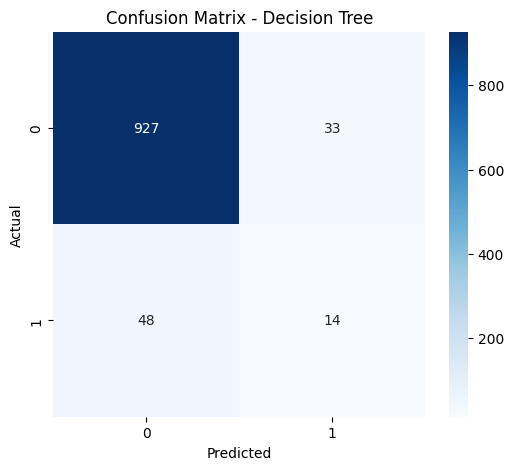

In [1947]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1948]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.30      0.23      0.26        62

    accuracy                           0.92      1022
   macro avg       0.62      0.60      0.61      1022
weighted avg       0.91      0.92      0.92      1022



In [1949]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy :", round(cv_scores.mean(), 4))

Cross Validation Scores
[0.91976517 0.91780822 0.90704501 0.91976517 0.92270059]

Average Accuracy : 0.9174


# L1 (LASSO) Regularization

In [1950]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1951]:
# Remove ID
df.drop("id", axis=1, inplace=True)

## Handle Missing Values

In [1952]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

knn = KNNImputer(n_neighbors=5)
df[numerical_columns] = knn.fit_transform(df[numerical_columns])
mode = SimpleImputer(strategy="most_frequent")
df[categorical_columns] = mode.fit_transform(df[categorical_columns])
df = df.dropna(subset=["stroke"])
df.reset_index(drop=True, inplace=True)

In [1953]:
# Encoding
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(
    df,
    columns=["work_type", "smoking_status"],
    drop_first=True
)

In [1954]:
# Feature Scaling
X = df.drop("stroke", axis=1)
y = df["stroke"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

### L1 (LASSO) Feature Selection

In [1955]:
lasso = LogisticRegression(
    l1_ratio=1,
    solver="saga",
    random_state=42,
    max_iter=1000
)

lasso.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [1956]:
selected_features = X.columns[lasso.coef_[0] != 0]
selected_features

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='str')

In [1957]:
lasso_scores = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_[0]
})

lasso_scores["Absolute Coefficient"] = lasso_scores["Coefficient"].abs()

lasso_scores = lasso_scores.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

lasso_scores

,Feature,Coefficient,Absolute Coefficient
1,age,1.590066,1.590066
11,work_type_children,0.209394,0.209394
6,avg_glucose_level,0.175550,0.175550
2,hypertension,0.121521,0.121521
10,work_type_Self-employed,-0.084302,0.084302
3,heart_disease,0.076091,0.076091
9,work_type_Private,0.065926,0.065926
14,smoking_status_smokes,0.057778,0.057778
13,smoking_status_never smoked,-0.050977,0.050977
5,Residence_type,0.050377,0.050377


In [1958]:
# Create Selected Feature Dataset
X_selected = X[selected_features]
X_selected.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.052604,-0.328865,4.18151,0.723256,0.983695,2.707557,0.863951,-0.436563,-0.394112,2.184951,-0.767096,-0.427313
1,0.787132,-0.328865,-0.23966,0.723256,-1.016576,2.122550,-1.157473,2.290621,-0.394112,-0.457676,1.303618,-0.427313
2,1.627792,-0.328865,4.18151,0.723256,-1.016576,-0.004729,0.863951,-0.436563,-0.394112,-0.457676,1.303618,-0.427313
3,0.256189,-0.328865,-0.23966,0.723256,0.983695,1.438127,0.863951,-0.436563,-0.394112,-0.457676,-0.767096,2.340204
4,1.583546,3.045637,-0.23966,0.723256,-1.016576,1.501974,-1.157473,2.290621,-0.394112,-0.457676,1.303618,-0.427313


In [1959]:
# Feature Selection Summary
summary = pd.DataFrame({
    "Original Features":[X.shape[1]],
    "Selected Features":[X_selected.shape[1]],
    "Removed Features":[X.shape[1]-X_selected.shape[1]]
})

print(
    tabulate(
        summary,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------+-------------------+------------------+
| Original Features | Selected Features | Removed Features |
+-------------------+-------------------+------------------+
|        15         |        12         |        3         |
+-------------------+-------------------+------------------+


In [1960]:
# Selected Features
print("Selected Features:")

for feature in selected_features:
    print(feature)

Selected Features:
age
hypertension
heart_disease
ever_married
Residence_type
avg_glucose_level
work_type_Private
work_type_Self-employed
work_type_children
smoking_status_formerly smoked
smoking_status_never smoked
smoking_status_smokes


In [1961]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 12)
Testing Set : (1022, 12)


In [1962]:
# Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [1963]:
# Train and Evaluate Models
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [1964]:
# Preformance Comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

results_df = results_df.round(2)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+------------------------+----------+-----------+--------+----------+
|         Model          | Accuracy | Precision | Recall | F1-score |
+------------------------+----------+-----------+--------+----------+
|  Logistic Regression   |   0.74   |   0.93    |  0.74  |   0.81   |
|     Decision Tree      |   0.92   |    0.9    |  0.92  |   0.91   |
|     Random Forest      |   0.94   |   0.92    |  0.94  |   0.92   |
| Support Vector Machine |   0.77   |   0.92    |  0.77  |   0.83   |
|        XGBoost         |   0.94   |    0.9    |  0.94  |   0.91   |
+------------------------+----------+-----------+--------+----------+


In [1965]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


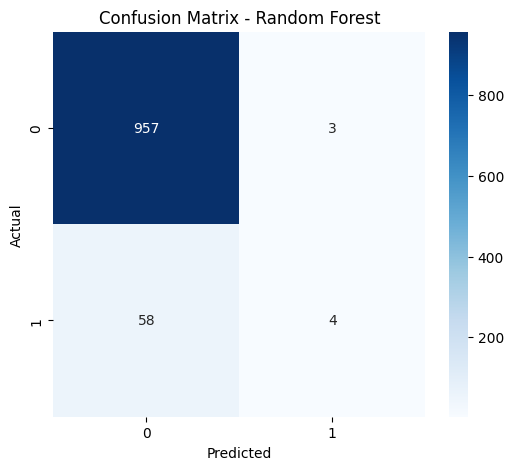

In [1966]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1967]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.57      0.06      0.12        62

    accuracy                           0.94      1022
   macro avg       0.76      0.53      0.54      1022
weighted avg       0.92      0.94      0.92      1022



In [1968]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy :", round(cv_scores.mean(), 4))

Cross Validation Scores
[0.94716243 0.94911937 0.94324853 0.94716243 0.94911937]

Average Accuracy : 0.9472


# TREE-BASED Feature Importance

In [1969]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1970]:
# Remove ID Column
df.drop("id", axis=1, inplace=True)

## Handle Missing Values

In [1971]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

knn = KNNImputer(n_neighbors=5)
df[numerical_columns] = knn.fit_transform(df[numerical_columns])
mode = SimpleImputer(strategy="most_frequent")
df[categorical_columns] = mode.fit_transform(df[categorical_columns])
df = df.dropna(subset=["stroke"])
df.reset_index(drop=True, inplace=True)

In [1972]:
# Encoding
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(
    df,
    columns=["work_type", "smoking_status"],
    drop_first=True
)

In [1973]:
# Feature Scaling
X = df.drop("stroke", axis=1)

y = df["stroke"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

### Train Random Forest for Feature Importance

In [1974]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [1975]:
# Feature Importance Scores
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
6,avg_glucose_level,0.276584
1,age,0.245602
7,bmi,0.241376
2,hypertension,0.031712
5,Residence_type,0.030844
3,heart_disease,0.028644
0,gender,0.028615
9,work_type_Private,0.023150
13,smoking_status_never smoked,0.021292
10,work_type_Self-employed,0.018788


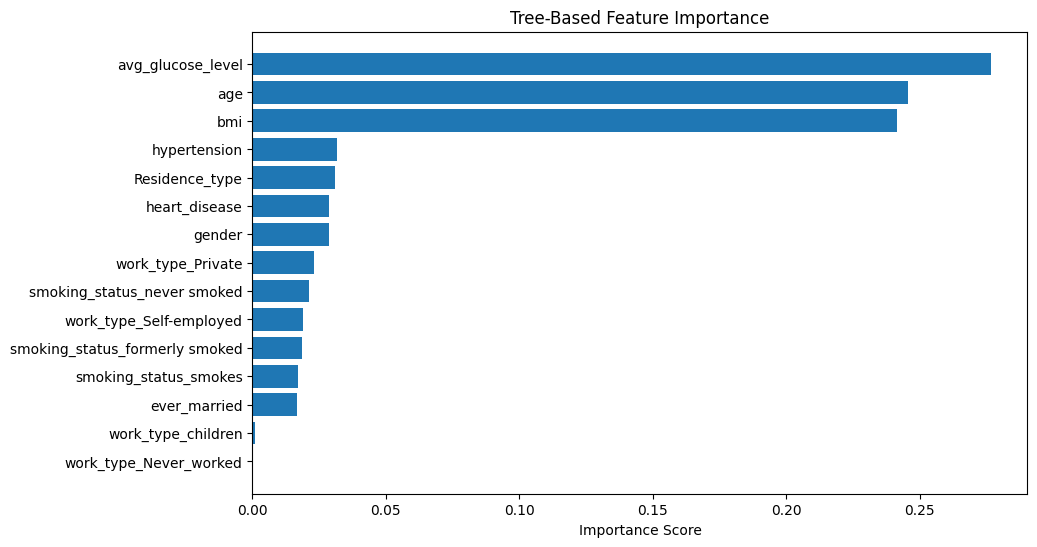

In [1976]:
# Visualize Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Tree-Based Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis() # eng balandidan pastga qaratib
plt.show()

In [1977]:
# Select Top Features
selected_features = feature_importance.head(10)["Feature"].tolist()
selected_features

X_selected = X[selected_features]
X_selected.head()

,avg_glucose_level,age,bmi,hypertension,Residence_type,heart_disease,gender,work_type_Private,smoking_status_never smoked,work_type_Self-employed
0,2.707557,1.052604,0.985739,-0.328865,0.983695,4.18151,1.188552,0.863951,-0.767096,-0.436563
1,2.122550,0.787132,0.313623,-0.328865,-1.016576,-0.23966,-0.840005,-1.157473,1.303618,2.290621
2,-0.004729,1.627792,0.457832,-0.328865,-1.016576,4.18151,1.188552,0.863951,1.303618,-0.436563
3,1.438127,0.256189,0.702472,-0.328865,0.983695,-0.23966,-0.840005,0.863951,-0.767096,-0.436563
4,1.501974,1.583546,-0.636608,3.045637,-1.016576,-0.23966,-0.840005,-1.157473,1.303618,2.290621


In [1978]:
# Feature Selection Summary
summary = pd.DataFrame({
    "Original Features": [X.shape[1]],
    "Selected Features": [X_selected.shape[1]],
    "Removed Features": [X.shape[1] - X_selected.shape[1]]
})

print(
    tabulate(
        summary,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------+-------------------+------------------+
| Original Features | Selected Features | Removed Features |
+-------------------+-------------------+------------------+
|        15         |        10         |        5         |
+-------------------+-------------------+------------------+


In [1979]:
# Selected Features
print("Selected Features:")

for feature in selected_features:
    print(feature)

Selected Features:
avg_glucose_level
age
bmi
hypertension
Residence_type
heart_disease
gender
work_type_Private
smoking_status_never smoked
work_type_Self-employed


In [1980]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 10)
Testing Set : (1022, 10)


In [1981]:
# Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [1982]:
    # Train and Evaluate Models
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [1983]:
# Preformance Comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

results_df = results_df.round(2)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+------------------------+----------+-----------+--------+----------+
|         Model          | Accuracy | Precision | Recall | F1-score |
+------------------------+----------+-----------+--------+----------+
|  Logistic Regression   |   0.74   |   0.93    |  0.74  |   0.81   |
|     Decision Tree      |   0.91   |    0.9    |  0.91  |   0.91   |
|     Random Forest      |   0.94   |   0.88    |  0.94  |   0.91   |
| Support Vector Machine |   0.77   |   0.92    |  0.77  |   0.83   |
|        XGBoost         |   0.93   |    0.9    |  0.93  |   0.91   |
+------------------------+----------+-----------+--------+----------+


In [1984]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Decision Tree


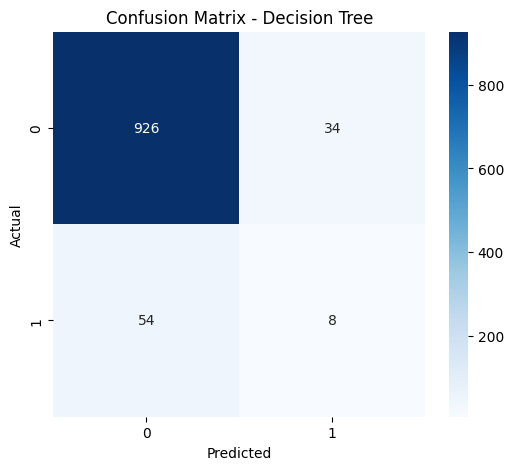

In [1985]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1986]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.19      0.13      0.15        62

    accuracy                           0.91      1022
   macro avg       0.57      0.55      0.55      1022
weighted avg       0.90      0.91      0.91      1022



In [1987]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy :", round(cv_scores.mean(), 4))

Cross Validation Scores
[0.91585127 0.91291585 0.91585127 0.91682975 0.92367906]

Average Accuracy : 0.917


# Principal Component Analysis (PCA)

In [1988]:
# Reload Dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046.0,Male,67.0,0.0,1.0,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676.0,Female,61.0,0.0,0.0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112.0,Male,80.0,0.0,1.0,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182.0,Female,49.0,0.0,0.0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665.0,Female,79.0,1.0,0.0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [1989]:
# Remove ID Column
df.drop("id", axis=1, inplace=True)

## Handle Missing Values

In [1990]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("stroke")

categorical_columns = df.select_dtypes(include="str").columns.tolist()

knn = KNNImputer(n_neighbors=5)

df[numerical_columns] = knn.fit_transform(df[numerical_columns])
mode = SimpleImputer(strategy="most_frequent")
df[categorical_columns] = mode.fit_transform(df[categorical_columns])
df = df.dropna(subset=["stroke"])
df.reset_index(drop=True, inplace=True)

In [1991]:
# Encoding
binary_columns = [
    "gender",
    "ever_married",
    "Residence_type"
]

le = LabelEncoder()

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(
    df,
    columns=["work_type", "smoking_status"],
    drop_first=True
)

In [1992]:
# Feature Scaling
X = df.drop("stroke", axis=1)

y = df["stroke"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

### Apply PCA

In [1993]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

In [1994]:
print("Original Features :", X.shape[1])
print("PCA Components :", X_pca.shape[1])

Original Features : 15
PCA Components : 12


In [1995]:
# Explained Variance Ratio
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_
})
explained_variance

,Principal Component,Explained Variance Ratio
0,PC1,0.201099
1,PC2,0.111059
2,PC3,0.095260
3,PC4,0.078412
4,PC5,0.076844
5,PC6,0.068499
6,PC7,0.064897
7,PC8,0.061610
8,PC9,0.059297
9,PC10,0.054716


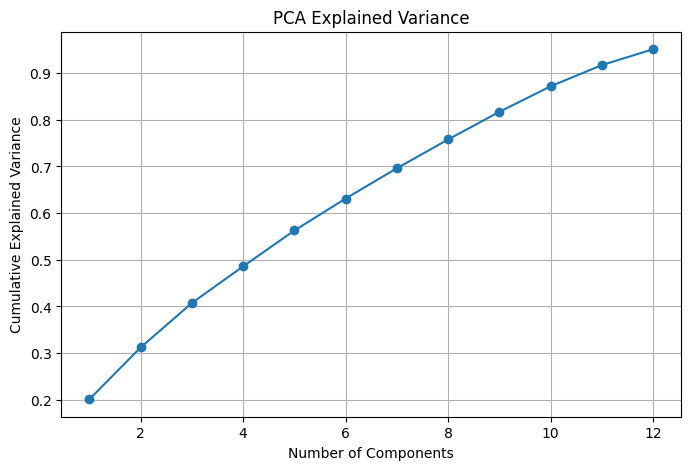

In [1996]:
# Cumulative Explained Variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)
plt.show()

In [1997]:
# PCA Summary
summary = pd.DataFrame({
    "Original Features": [X.shape[1]],
    "PCA Components": [X_pca.shape[1]],
    "Variance Retained (%)": [round(np.sum(pca.explained_variance_ratio_) * 100, 2)]
})

print(
    tabulate(
        summary,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------+----------------+-----------------------+
| Original Features | PCA Components | Variance Retained (%) |
+-------------------+----------------+-----------------------+
|       15.0        |      12.0      |         95.11         |
+-------------------+----------------+-----------------------+


In [1998]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,y,test_size=0.2,random_state=42)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (4088, 12)
Testing Set : (1022, 12)


In [1999]:
# Models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss")
}

In [ ]:
# Train and Evaluate Models
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [2001]:
# Preformance Comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

results_df = results_df.round(2)

print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+------------------------+----------+-----------+--------+----------+
|         Model          | Accuracy | Precision | Recall | F1-score |
+------------------------+----------+-----------+--------+----------+
|  Logistic Regression   |   0.71   |   0.93    |  0.71  |   0.79   |
|     Decision Tree      |   0.91   |    0.9    |  0.91  |   0.9    |
|     Random Forest      |   0.94   |   0.88    |  0.94  |   0.91   |
| Support Vector Machine |   0.74   |   0.92    |  0.74  |   0.81   |
|        XGBoost         |   0.94   |    0.9    |  0.94  |   0.91   |
+------------------------+----------+-----------+--------+----------+


In [2002]:
# Best Model
best_model_name = results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


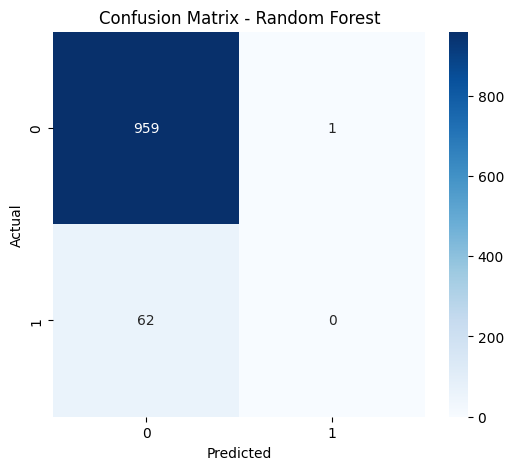

In [2003]:
# Confusion Matrix
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [2004]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [2005]:
# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X_selected,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy :", round(cv_scores.mean(), 4))

Cross Validation Scores
[0.94911937 0.95009785 0.94716243 0.95107632 0.95205479]

Average Accuracy : 0.9499


# Final Comparison of Feature Engineering Techniques

In [ ]:
# !!!
# The evaluation metrics were calculated using the weighted average to account for the class imbalance present in the stroke dataset.

In [2009]:
comparison = pd.DataFrame({

    "Method":[
        "Baseline",
        "Correlation Filtering",
        "Mutual Information",
        "ANOVA F-Test",
        "L1 (LASSO)",
        "Tree-Based Feature Importance",
        "PCA"
    ],

    "Best Model":[
        "XGBoost",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Accuracy":[
        0.94,
        0.74,
        0.74,
        0.74,
        0.74,
        0.74,
        0.71
    ],

    "Precision":[
        0.92,
        0.14,
        0.16,
        0.16,
        0.16,
        0.16,
        0.15
    ],

    "Recall":[
        0.94,
        0.80,
        0.79,
        0.76,
        0.81,
        0.82,
        0.82
    ],

    "F1-score":[
        0.92,
        0.23,
        0.27,
        0.26,
        0.27,
        0.27,
        0.26
    ]

})

comparison = comparison.round(2)

print(
    tabulate(
        comparison,
        headers="keys",
        tablefmt="pretty",
        showindex=False
    )
)

+-------------------------------+---------------------+----------+-----------+--------+----------+
|            Method             |     Best Model      | Accuracy | Precision | Recall | F1-score |
+-------------------------------+---------------------+----------+-----------+--------+----------+
|           Baseline            |       XGBoost       |   0.94   |   0.92    |  0.94  |   0.92   |
|     Correlation Filtering     | Logistic Regression |   0.74   |   0.14    |  0.8   |   0.23   |
|      Mutual Information       | Logistic Regression |   0.74   |   0.16    |  0.79  |   0.27   |
|         ANOVA F-Test          | Logistic Regression |   0.74   |   0.16    |  0.76  |   0.26   |
|          L1 (LASSO)           | Logistic Regression |   0.74   |   0.16    |  0.81  |   0.27   |
| Tree-Based Feature Importance | Logistic Regression |   0.74   |   0.16    |  0.82  |   0.27   |
|              PCA              | Logistic Regression |   0.71   |   0.15    |  0.82  |   0.26   |
+---------